In [1]:
import os
import numpy as np

from PIL import Image
%load_ext autoreload
%autoreload 2

# Make a dataloader that mixes wevrything randomly loads the images splits a train and test and computes the embeddings
from pathlib import Path

from data_handler import EleHandler
from seek_code import SEEK
from concept_head import ConceptHead

from torch.utils.data import DataLoader
from torch.utils.data.sampler import RandomSampler, SubsetRandomSampler
from torchvision import transforms as T


/data/vision/beery/scratch/antoine/micromamba/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Trying implementing the ears

Using cache found in /data/vision/beery/scratch/antoine/.cache/torch/hub/ultralytics_yolov5_master
YOLOv5 🚀 2024-11-18 Python-3.13.0 torch-2.5.1.post302 CUDA:0 (NVIDIA A100-SXM4-80GB, 81038MiB)

Fusing layers... 
Model summary: 213 layers, 1761871 parameters, 0 gradients, 4.1 GFLOPs
Adding AutoShape... 
/data/vision/beery/scratch/antoine/.cache/torch/hub/ultralytics_yolov5_master/models/common.py:892: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):


found  2  ears
Ear sides: ['left', 'right']
image 1/1: 831x1254 1 right, 1 left
Speed: 102.9ms pre-process, 97.3ms inference, 385.6ms NMS per image at shape (1, 3, 448, 640)
elephant # 273  - images SEEK: C00T_1E9988-0000X00S00


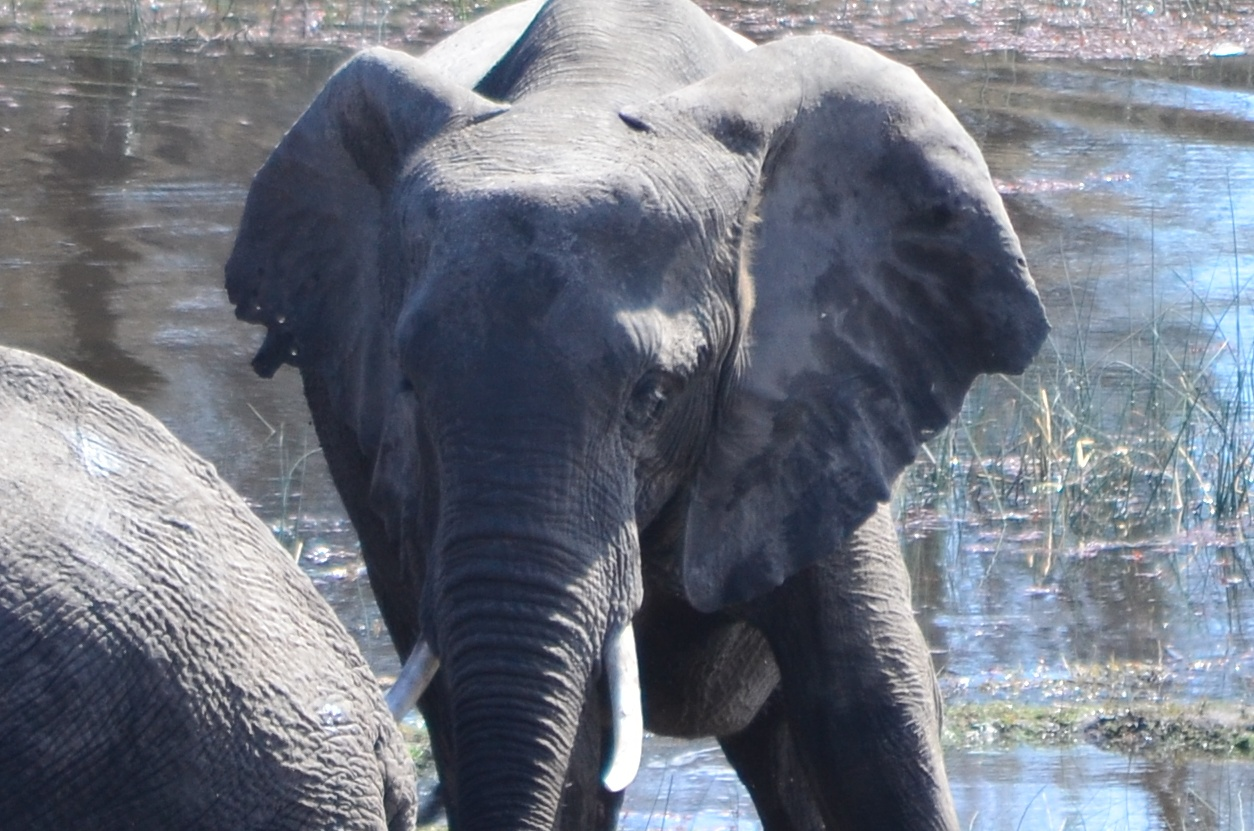

ear # 1


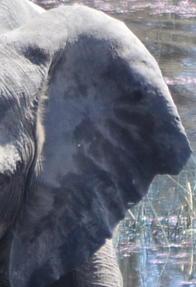

ear # 2


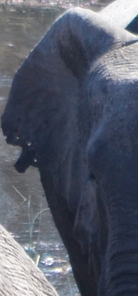

In [2]:
import random, torch
dataset = EleHandler( )

ear_detector = torch.hub.load("ultralytics/yolov5", "custom", path='/data/vision/beery/scratch/antoine/CBM_reid/weights/ear_YOLOv5_n.pt')

# Choose a random index from the dataset
idx = random.choice(range(len(dataset)))
dataset = EleHandler()
image = dataset.get_original_image(idx)

# inger the model to find the ears
output = ear_detector(dataset.get_original_image(idx))
print('found ', len(output.pred[0].tolist()), ' ears')


# Extract the side of the ears (left or right) from output
ear_sides = [output.names[int(det[-1])] for det in output.pred[0].tolist()]
print('Ear sides:', ear_sides)


xyxy = output.xyxy[0].tolist()

cropped_ears = [None] * len(xyxy)

print(output)
print('elephant #', dataset[idx][2], ' - images SEEK:', dataset[idx][8])
display(image)

for i in range(len(xyxy)):
    print('ear #', i+1)
    cropped_ears[i] = image.crop(tuple(xyxy[i][:4]))
    cropped_ears[i] = cropped_ears[i].resize((cropped_ears[i].width // 2, cropped_ears[i].height // 2))
    display(cropped_ears[i])

/data/vision/beery/scratch/antoine/.cache/torch/hub/ultralytics_yolov5_master/models/common.py:892: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):


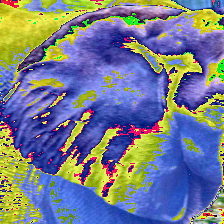

right


In [3]:

def crop_ears(original_image):
    '''
    Input : a non-transformed image
    Output : a list of two cropped ears, resized to 224x224, normalized to be embedded
    '''
    with torch.inference_mode():
        # infer with the ear detector (a pre-trained YOLOv5 model)
        output = ear_detector(original_image)

        # extract the bounding boxes of the detected ears
        xyxy = output.xyxy[0].tolist()

        # Extract the side of the ears (left or right) from output
        ear_sides = [output.names[int(det[-1])] for det in output.pred[0].tolist()]

        cropped_ears = [None] * len(xyxy)  

        # Go over the detected ears, crop them and transform them to a normalized tenser
        for j in range(min(len(xyxy),2)):            
            cropped_ears[j]= T.Compose([
                    T.Lambda(lambda img: img.crop(tuple(xyxy[j][:4]))),
                    T.Resize([224, 224]),
                    T.ToTensor(),
                    T.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225))
                ])(original_image)

        # Matching the ears to the correct side
        left_ear, right_ear = None, None
        for i, side in enumerate(ear_sides):
            if side == "left":
                left_ear = cropped_ears[i]
            elif side == "right":
                right_ear = cropped_ears[i]

    return left_ear, right_ear

# test
original_image = dataset.get_original_image(random.choice(range(len(dataset))))
left_ear, right_ear = crop_ears(original_image)

if left_ear is not None: 
    display(T.ToPILImage()(left_ear))
    print('left')
if right_ear is not None: 
    display(T.ToPILImage()(right_ear))
    print('right')

# Cutting along encounters vs cutting randomly

In [4]:
dataset = EleHandler()

# Create Random loader
indices = np.random.permutation(len(dataset))
train_split, val_split = int(0.7 * len(dataset)), int(0.15 * len(dataset))

random_train_loader = DataLoader(dataset, batch_size=512, sampler=SubsetRandomSampler(indices[:train_split]), num_workers=4)
random_val_loader = DataLoader(dataset, batch_size=512, sampler=SubsetRandomSampler(indices[train_split:train_split + val_split]), num_workers=4)
random_test_loader = DataLoader(dataset, batch_size=512, sampler=SubsetRandomSampler(indices[train_split + val_split:]), num_workers=4)

In [5]:
# Train and test the model wit random cuts
ch = ConceptHead(print_every=1)
ch.train(random_train_loader, random_val_loader, num_epochs= 50)
_,_ = ch.test(random_test_loader)

Epoch 1/50 - Train Loss: 0.1551, Val Loss: 0.1238 - Train Acc: 60.73%, Val Acc: 67.38% - Train whole-code: 0.23%, Val whole-code: 0.40%
Epoch 2/50 - Train Loss: 0.1211, Val Loss: 0.1189 - Train Acc: 67.90%, Val Acc: 68.32% - Train whole-code: 1.20%, Val whole-code: 1.21%
Epoch 3/50 - Train Loss: 0.1155, Val Loss: 0.1160 - Train Acc: 69.03%, Val Acc: 68.81% - Train whole-code: 1.85%, Val whole-code: 2.19%
Epoch 4/50 - Train Loss: 0.1117, Val Loss: 0.1121 - Train Acc: 69.93%, Val Acc: 69.85% - Train whole-code: 2.26%, Val whole-code: 2.27%
Epoch 5/50 - Train Loss: 0.1082, Val Loss: 0.1113 - Train Acc: 70.75%, Val Acc: 69.90% - Train whole-code: 2.40%, Val whole-code: 2.96%
Epoch 6/50 - Train Loss: 0.1060, Val Loss: 0.1107 - Train Acc: 71.34%, Val Acc: 70.08% - Train whole-code: 3.35%, Val whole-code: 3.06%
Epoch 7/50 - Train Loss: 0.1042, Val Loss: 0.1093 - Train Acc: 71.95%, Val Acc: 70.38% - Train whole-code: 3.78%, Val whole-code: 2.85%
Epoch 8/50 - Train Loss: 0.1024, Val Loss: 0.108

KeyboardInterrupt: 

In [2]:
# Create dataset and dataloaders
dataset = EleHandler()

# I cut along the encounters to make sure that the same encounter is not in both train and test (with the criteria that two images taken less than 2 hours appart are in the same encounter)
train_indices, val_indices, test_indices = dataset.split_along_encounters([0.7,0.15,0.15])

train_loader, val_loader, test_loader = (DataLoader(dataset, batch_size=128, sampler=RandomSampler(indices), num_workers=4) for indices in [train_indices, val_indices, test_indices])


ch = ConceptHead(print_every=1)
ch.train(train_loader, val_loader, num_epochs= 50)
_,_ = ch.test(test_loader)

Filtered dictionary #season unique values: ['EFA_IDU' 'EFA_IDI']
Train indices: 6108, Validation indices: 1101, Test indices: 1235
Epoch 1/50 - Train Loss: 0.1301, Val Loss: 0.1159 - Train Acc: 64.68%, Val Acc: 68.10% - Train whole-code: 0.26%, Val whole-code: 0.78%
Epoch 2/50 - Train Loss: 0.1111, Val Loss: 0.1079 - Train Acc: 69.10%, Val Acc: 70.44% - Train whole-code: 1.24%, Val whole-code: 2.05%
Epoch 3/50 - Train Loss: 0.1050, Val Loss: 0.1056 - Train Acc: 71.16%, Val Acc: 70.60% - Train whole-code: 2.36%, Val whole-code: 2.46%
Epoch 4/50 - Train Loss: 0.1015, Val Loss: 0.1010 - Train Acc: 72.34%, Val Acc: 72.19% - Train whole-code: 3.08%, Val whole-code: 2.63%


KeyboardInterrupt: 

In [13]:
# Create dataset and dataloaders
dataset = EleHandler()

# I cut along the encounters to make sure that the same encounter is not in both train and test (with the criteria that two images taken less than 2 hours appart are in the same encounter)
train_indices, val_indices, test_indices = dataset.split_along_encounters([0.7,0.15,0.15])

train_loader, val_loader, test_loader = (DataLoader(dataset, batch_size=128, sampler=RandomSampler(indices), num_workers=4) for indices in [train_indices, val_indices, test_indices])


ch = ConceptHead(print_every=1)
ch.train(train_loader, val_loader, num_epochs= 50)
_,_ = ch.test(test_loader)

Train indices: 6108, Validation indices: 1101, Test indices: 1235
Epoch 1/50 - Train Loss: 0.1300, Val Loss: 0.1162 - Train Acc: 65.21%, Val Acc: 68.40% - Train whole-code: 1.00%, Val whole-code: 0.84%
Epoch 2/50 - Train Loss: 0.1119, Val Loss: 0.1087 - Train Acc: 69.29%, Val Acc: 70.55% - Train whole-code: 1.52%, Val whole-code: 1.76%
Epoch 3/50 - Train Loss: 0.1057, Val Loss: 0.1058 - Train Acc: 71.24%, Val Acc: 70.84% - Train whole-code: 2.43%, Val whole-code: 2.00%
Epoch 4/50 - Train Loss: 0.1020, Val Loss: 0.1013 - Train Acc: 72.31%, Val Acc: 72.54% - Train whole-code: 3.37%, Val whole-code: 3.33%
Epoch 5/50 - Train Loss: 0.0990, Val Loss: 0.0989 - Train Acc: 73.15%, Val Acc: 73.20% - Train whole-code: 3.89%, Val whole-code: 3.67%
Epoch 6/50 - Train Loss: 0.0964, Val Loss: 0.0953 - Train Acc: 73.89%, Val Acc: 74.28% - Train whole-code: 4.63%, Val whole-code: 3.85%
Epoch 7/50 - Train Loss: 0.0940, Val Loss: 0.0938 - Train Acc: 74.71%, Val Acc: 74.61% - Train whole-code: 4.38%, Val 

# Choosing the loss : MSE vs C-E vs Homemade C-E ?

In [5]:
import torch.nn as nn

# Create dataset and dataloaders
dataset = EleHandler()

# I cut along the encounters to make sure that the same encounter is not in both train and test (with the criteria that two images taken less than 2 hours appart are in the same encounter)
train_indices, val_indices, test_indices = dataset.split_along_encounters([0.7,0.15,0.15], )

train_loader, val_loader, test_loader = (DataLoader(dataset, batch_size=512, sampler=RandomSampler(indices), num_workers=4) for indices in [train_indices, val_indices, test_indices])

Unique groups: 542
Train indices: 6108, Validation indices: 1101, Test indices: 1235


In [ ]:
# cross-entropy loss
from backbone import Backbone
backbone = Backbone(pretraining="savanah_elephants")
backbone.freeze()

ch_ce = ConceptHead(loss=nn.CrossEntropyLoss(), print_every=1, experiment_code = 'ce')
history_ce = ch_ce.train(train_loader, val_loader, backbone, num_epochs= 200)
ch_ce.test(test_loader)

TypeError: ConceptHead.train() missing 1 required positional argument: 'backbone'

In [ ]:
import torch.nn as nn

# cross-entropy loss
ch_mse = ConceptHead(print_every=1)
history_mse = ch_mse.train(train_loader, val_loader, num_epochs= 200)
_, _ = ch_mse.test(test_loader)

/data/vision/beery/scratch/antoine/CBM_reid/methods/concept_head.py:40: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(Path(__file__).parent.parent / 

Epoch 1/200 - Train Loss: 0.1556, Val Loss: 0.1245 - Train Acc: 59.67%, Val Acc: 67.00% - Train whole-code: 0.10%, Val whole-code: 0.13%
Epoch 2/200 - Train Loss: 0.1220, Val Loss: 0.1180 - Train Acc: 66.44%, Val Acc: 68.03% - Train whole-code: 0.10%, Val whole-code: 0.00%
Epoch 3/200 - Train Loss: 0.1164, Val Loss: 0.1150 - Train Acc: 67.94%, Val Acc: 68.98% - Train whole-code: 0.41%, Val whole-code: 0.33%
Epoch 4/200 - Train Loss: 0.1126, Val Loss: 0.1125 - Train Acc: 69.19%, Val Acc: 69.77% - Train whole-code: 0.80%, Val whole-code: 0.85%
Epoch 5/200 - Train Loss: 0.1092, Val Loss: 0.1094 - Train Acc: 70.34%, Val Acc: 70.70% - Train whole-code: 1.93%, Val whole-code: 1.58%
Epoch 6/200 - Train Loss: 0.1071, Val Loss: 0.1069 - Train Acc: 71.06%, Val Acc: 71.06% - Train whole-code: 2.13%, Val whole-code: 1.54%
Epoch 7/200 - Train Loss: 0.1051, Val Loss: 0.1093 - Train Acc: 71.72%, Val Acc: 69.88% - Train whole-code: 2.67%, Val whole-code: 1.84%
Epoch 8/200 - Train Loss: 0.1031, Val Los

In [ ]:
def split_outputs(prob_vector):
    """
    Converts a probability one-hot predicted tensor into a list of smaller tensors, each representing an attribute
    """
    val_prob_list = []
    index = 0

    for att in SEEK.attribute_names:
        slice_length = SEEK.lengths[att]
        prob_slice = prob_vector[:, index:index + slice_length]
        val_prob_list.append(prob_slice)
        
        index += slice_length

    return val_prob_list


def character_regularized_loss(outputs, labels, main_loss_fn = nn.MSELoss()):

    """
    Computes the loss of the model such that each attribute of the SEEK code is assessed equally, regardless of the number of values it can take (and of the size of its one-hot econding)
    """
    outputs_list = split_outputs(outputs)
    labels_list = split_outputs(labels)

    loss = 0
    for i in range(len(outputs_list)):
        loss += main_loss_fn(outputs_list[i], labels_list[i])/SEEK.lengths[SEEK.attribute_names[i]]

    return loss

# cross-entropy loss
# Are the asumptiuns respected for this loss ?
ch_homemade = ConceptHead(loss=character_regularized_loss, print_every=1, experiment_code = 'homemade')
history_homemade = ch_homemade.train(train_loader, val_loader, num_epochs= 200)
_, _ = ch_homemade.test(test_loader)

Epoch 1/200 - Train Loss: 0.5434, Val Loss: 0.4743 - Train Acc: 64.18%, Val Acc: 68.16% - Train whole code: 0.54%, Val whole code: 1.04%
Epoch 2/200 - Train Loss: 0.4655, Val Loss: 0.4606 - Train Acc: 67.99%, Val Acc: 68.33% - Train whole code: 1.15%, Val whole code: 1.39%
Epoch 3/200 - Train Loss: 0.4495, Val Loss: 0.4434 - Train Acc: 69.26%, Val Acc: 69.63% - Train whole code: 1.71%, Val whole code: 1.24%
Epoch 4/200 - Train Loss: 0.4383, Val Loss: 0.4398 - Train Acc: 69.89%, Val Acc: 69.57% - Train whole code: 2.25%, Val whole code: 1.88%
Epoch 5/200 - Train Loss: 0.4264, Val Loss: 0.4359 - Train Acc: 70.80%, Val Acc: 70.12% - Train whole code: 2.43%, Val whole code: 1.68%
Epoch 6/200 - Train Loss: 0.4201, Val Loss: 0.4231 - Train Acc: 71.29%, Val Acc: 71.08% - Train whole code: 2.91%, Val whole code: 2.23%
Epoch 7/200 - Train Loss: 0.4146, Val Loss: 0.4181 - Train Acc: 71.57%, Val Acc: 71.31% - Train whole code: 2.89%, Val whole code: 2.02%
Epoch 8/200 - Train Loss: 0.4105, Val Los

# Quick look at the predictions

In [ ]:
from collections import Counter

dataset = EleHandler()
ch = ConceptHead()
images, embeddings, predictions, labels, outputs = ch.infer_all(dataset)

predictions_S =[SEEK(p) for p in predictions]

# Dictionary to store counts for each attribute
attribute_counts = {attribute: Counter() for attribute in SEEK.attribute_names}

# Iterate over all predictions and count attribute values
for seek_obj in predictions_S:
    for attribute in SEEK.attribute_names:
        attribute_value = getattr(seek_obj, attribute)  # Get the value of the attribute
        attribute_counts[attribute][attribute_value] += 1

# Display results
for attribute, counts in attribute_counts.items():
    print(f"Attribute: {attribute}")
    for value, count in counts.items():
        print(f"  Value {value}: {count} times")

        

Attribute: sex
  Value B: 8444 times
Attribute: age
  Value 00: 8443 times
  Value 20: 1 times
Attribute: right_tusk
  Value 1: 8161 times
  Value _: 283 times
Attribute: left_tusk
  Value 1: 8040 times
  Value _: 404 times
Attribute: R_tear_1
  Value _: 3903 times
  Value 0: 3000 times
  Value 8: 851 times
  Value 9: 641 times
  Value 7: 49 times
Attribute: R_hole_1
  Value 0: 6298 times
  Value _: 2141 times
  Value 9: 5 times
Attribute: R_tear_2
  Value 0: 5746 times
  Value _: 2616 times
  Value 8: 61 times
  Value 9: 12 times
  Value 7: 9 times
Attribute: R_hole_2
  Value _: 1938 times
  Value 0: 6504 times
  Value 8: 2 times
Attribute: L_tear_1
  Value _: 2813 times
  Value 0: 4253 times
  Value 3: 491 times
  Value 4: 863 times
  Value 5: 24 times
Attribute: L_hole_1
  Value _: 1764 times
  Value 0: 6659 times
  Value 4: 12 times
  Value 5: 5 times
  Value 3: 4 times
Attribute: L_tear_2
  Value _: 1977 times
  Value 0: 6394 times
  Value 3: 14 times
  Value 4: 50 times
  Value 5

# t-SNE

In [18]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE



# Prepare grid dimensions
num_attributes = len(SEEK.attribute_names)
num_cols = 3
num_rows = (num_attributes + num_cols - 1) // num_cols

fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, num_rows * 5))

# Loop through attributes
for i, attribute in enumerate(SEEK.attribute_names):

    # Perform t-SNE
    tsne = TSNE(n_components=2, perplexity=15, random_state=42)
    tsne_result = tsne.fit_transform(val_prob_list[i])

    # Get labels for coloring
    y = [getattr(SEEK(predictions[j]), attribute) for j in range(len(predictions))]

    # Create a DataFrame for plotting
    tsne_result_df = pd.DataFrame({'tsne_1': tsne_result[:, 0], 'tsne_2': tsne_result[:, 1], 'label': y})
    # Replace "_" with "Underscore" or similar
    tsne_result_df['label'] = tsne_result_df['label'].replace("_", "?")


    # Plot scatterplot
    ax = axes[i // num_cols, i % num_cols]
    sns.scatterplot(
        x='tsne_1', 
        y='tsne_2', 
        hue='label', 
        data=tsne_result_df, 
        ax=ax, 
        s=15, 
        palette='pastel'  # Customize palette as needed
    )
    ax.set_title(f't-SNE for {attribute}', fontsize=12)
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Labels', fontsize=8)
    ax.set_aspect('equal')



# Remove unused subplots
for j in range(num_attributes, num_rows * num_cols):
    fig.delaxes(axes[j // num_cols, j % num_cols])

# Tight layout for neat display
plt.tight_layout()
plt.show()


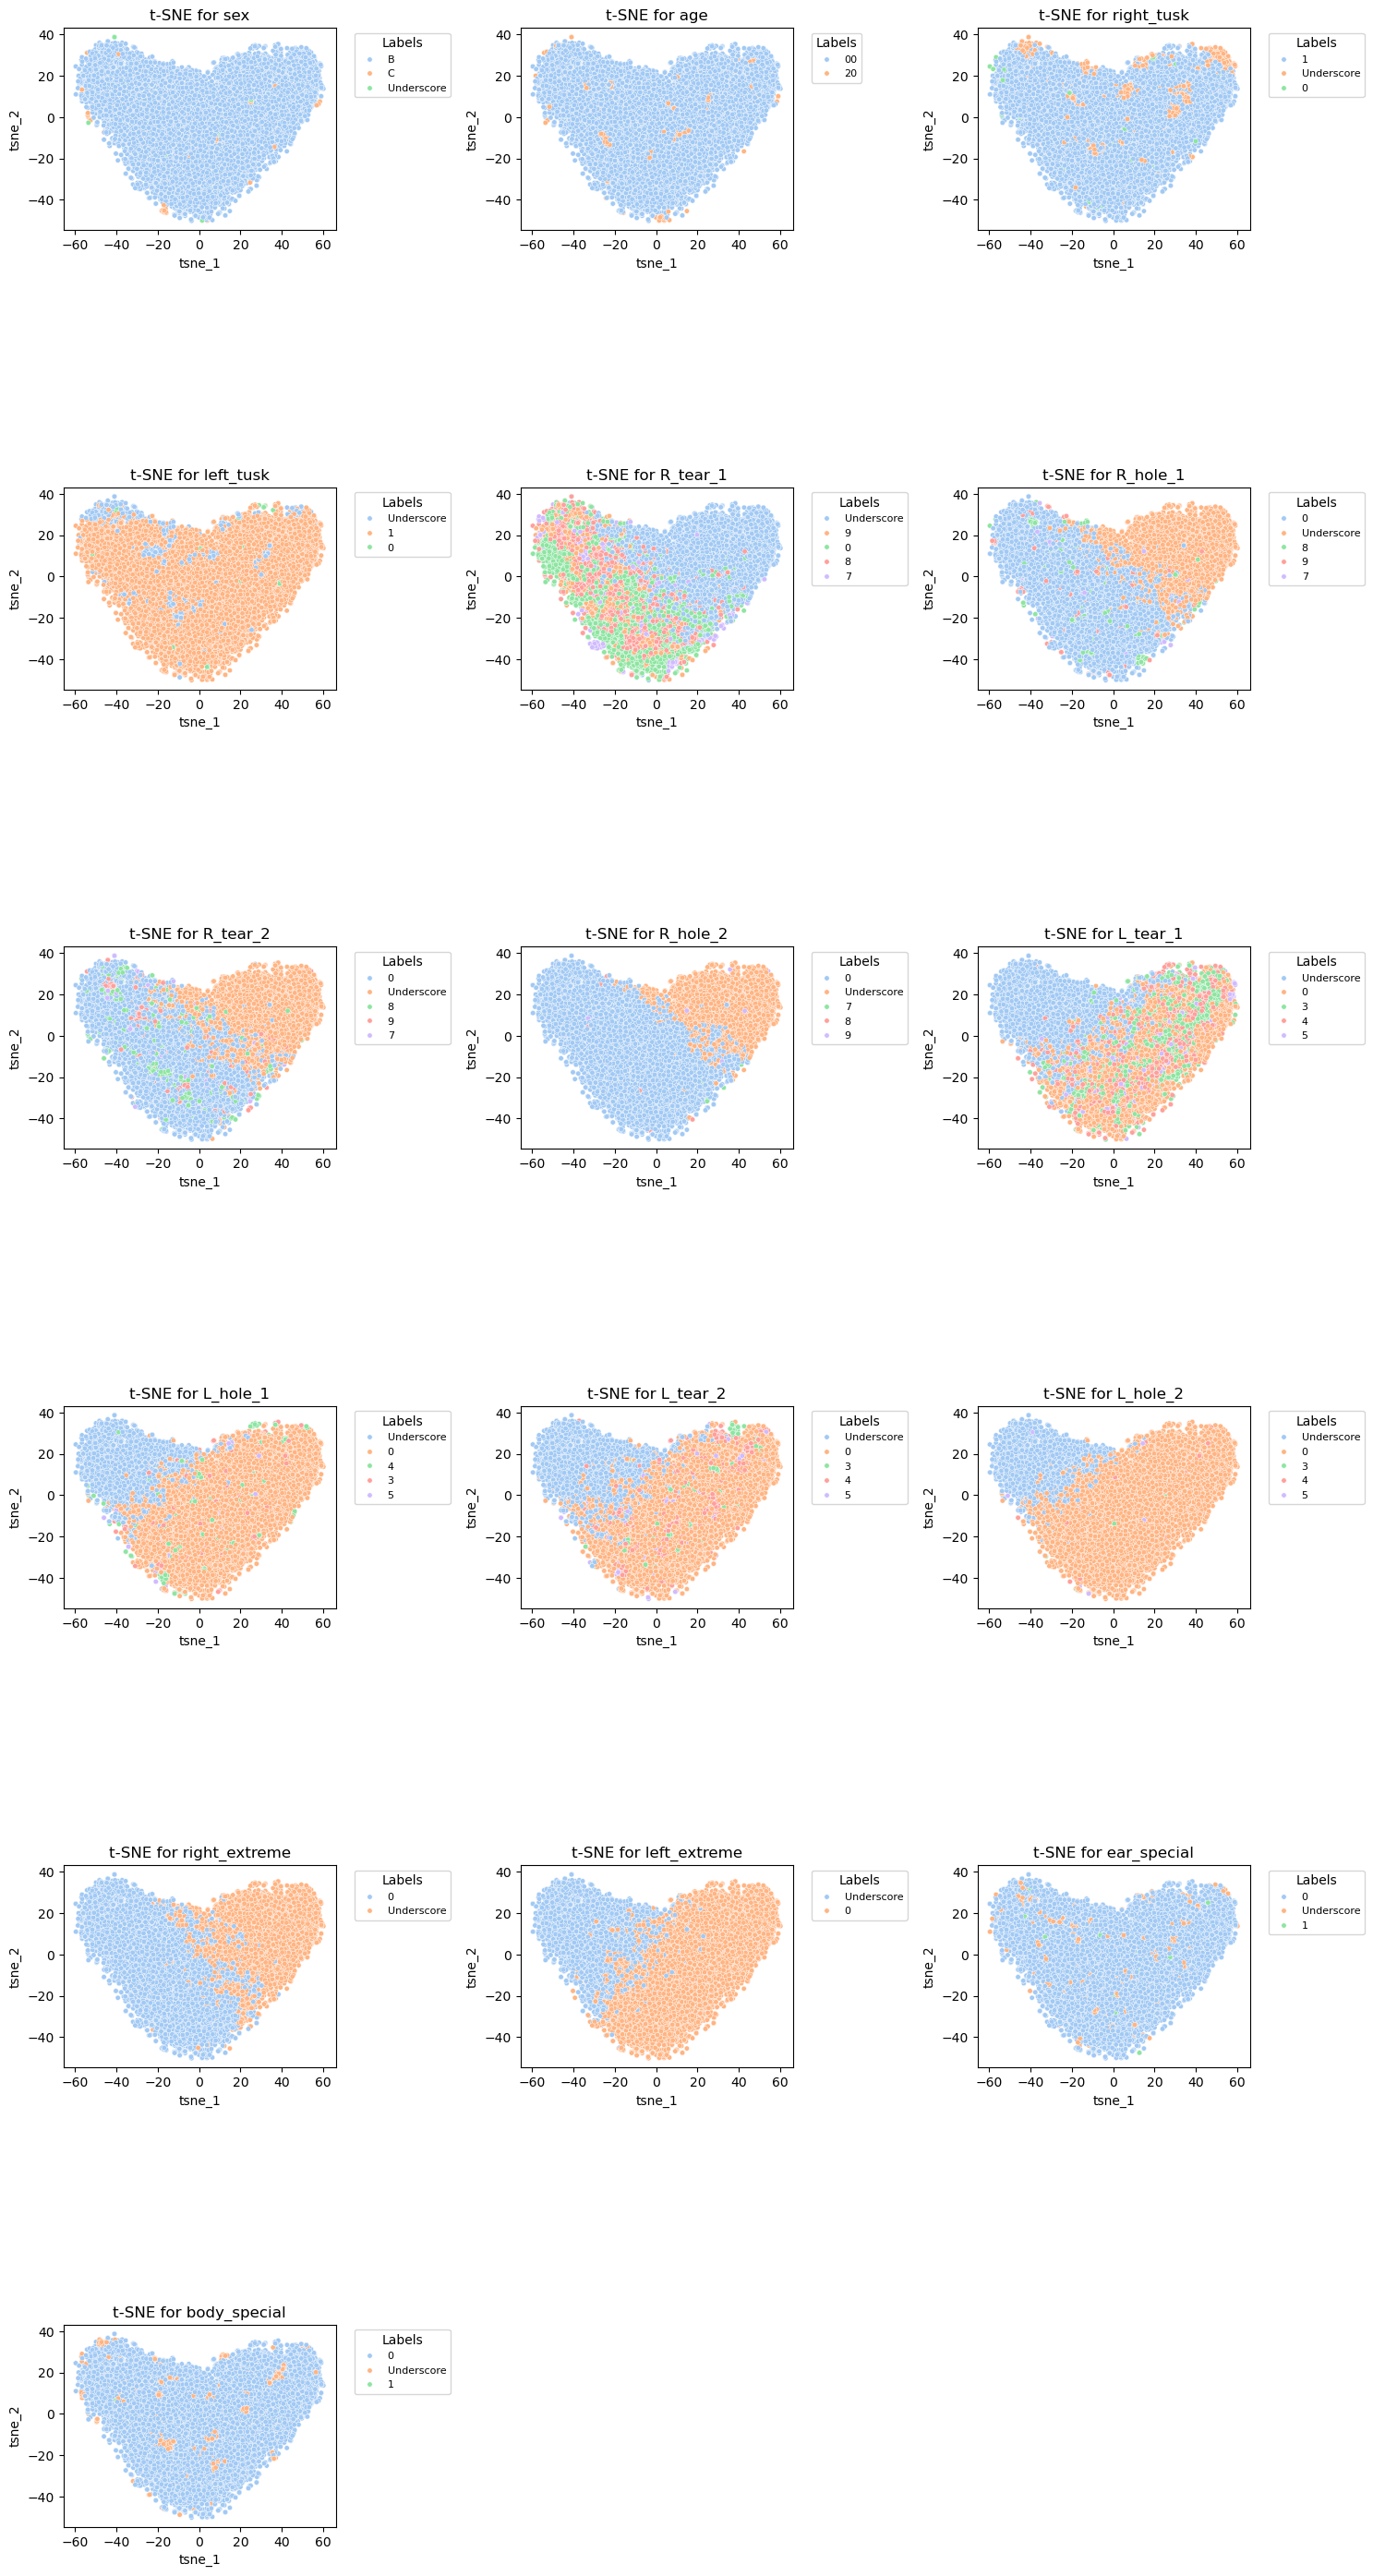

In [123]:
# Prepare grid dimensions
num_attributes = len(SEEK.attribute_names)
num_cols = 3
num_rows = (num_attributes + num_cols - 1) // num_cols

fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, num_rows * 5))
# Perform t-SNE
tsne = TSNE(n_components=2, perplexity=50, random_state=42)
tsne_result = tsne.fit_transform(outputs)

# Loop through attributes
for i, attribute in enumerate(SEEK.attribute_names):


    # Get labels for coloring
    y = [getattr(SEEK(predictions[j]), attribute) for j in range(len(predictions))]

    # Create a DataFrame for plotting
    tsne_result_df = pd.DataFrame({'tsne_1': tsne_result[:, 0], 'tsne_2': tsne_result[:, 1], 'label': y})
    # Replace "_" with "Underscore" or similar
    tsne_result_df['label'] = tsne_result_df['label'].replace("_", "Underscore")


    # Plot scatterplot
    ax = axes[i // num_cols, i % num_cols]
    sns.scatterplot(
        x='tsne_1', 
        y='tsne_2', 
        hue='label', 
        data=tsne_result_df, 
        ax=ax, 
        s=15, 
        palette='pastel'  # Customize palette as needed
    )
    ax.set_title(f't-SNE for {attribute}', fontsize=12)
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Labels', fontsize=8)
    ax.set_aspect('equal')



# Remove unused subplots
for j in range(num_attributes, num_rows * num_cols):
    fig.delaxes(axes[j // num_cols, j % num_cols])

# Tight layout for neat display
plt.tight_layout()
plt.show()

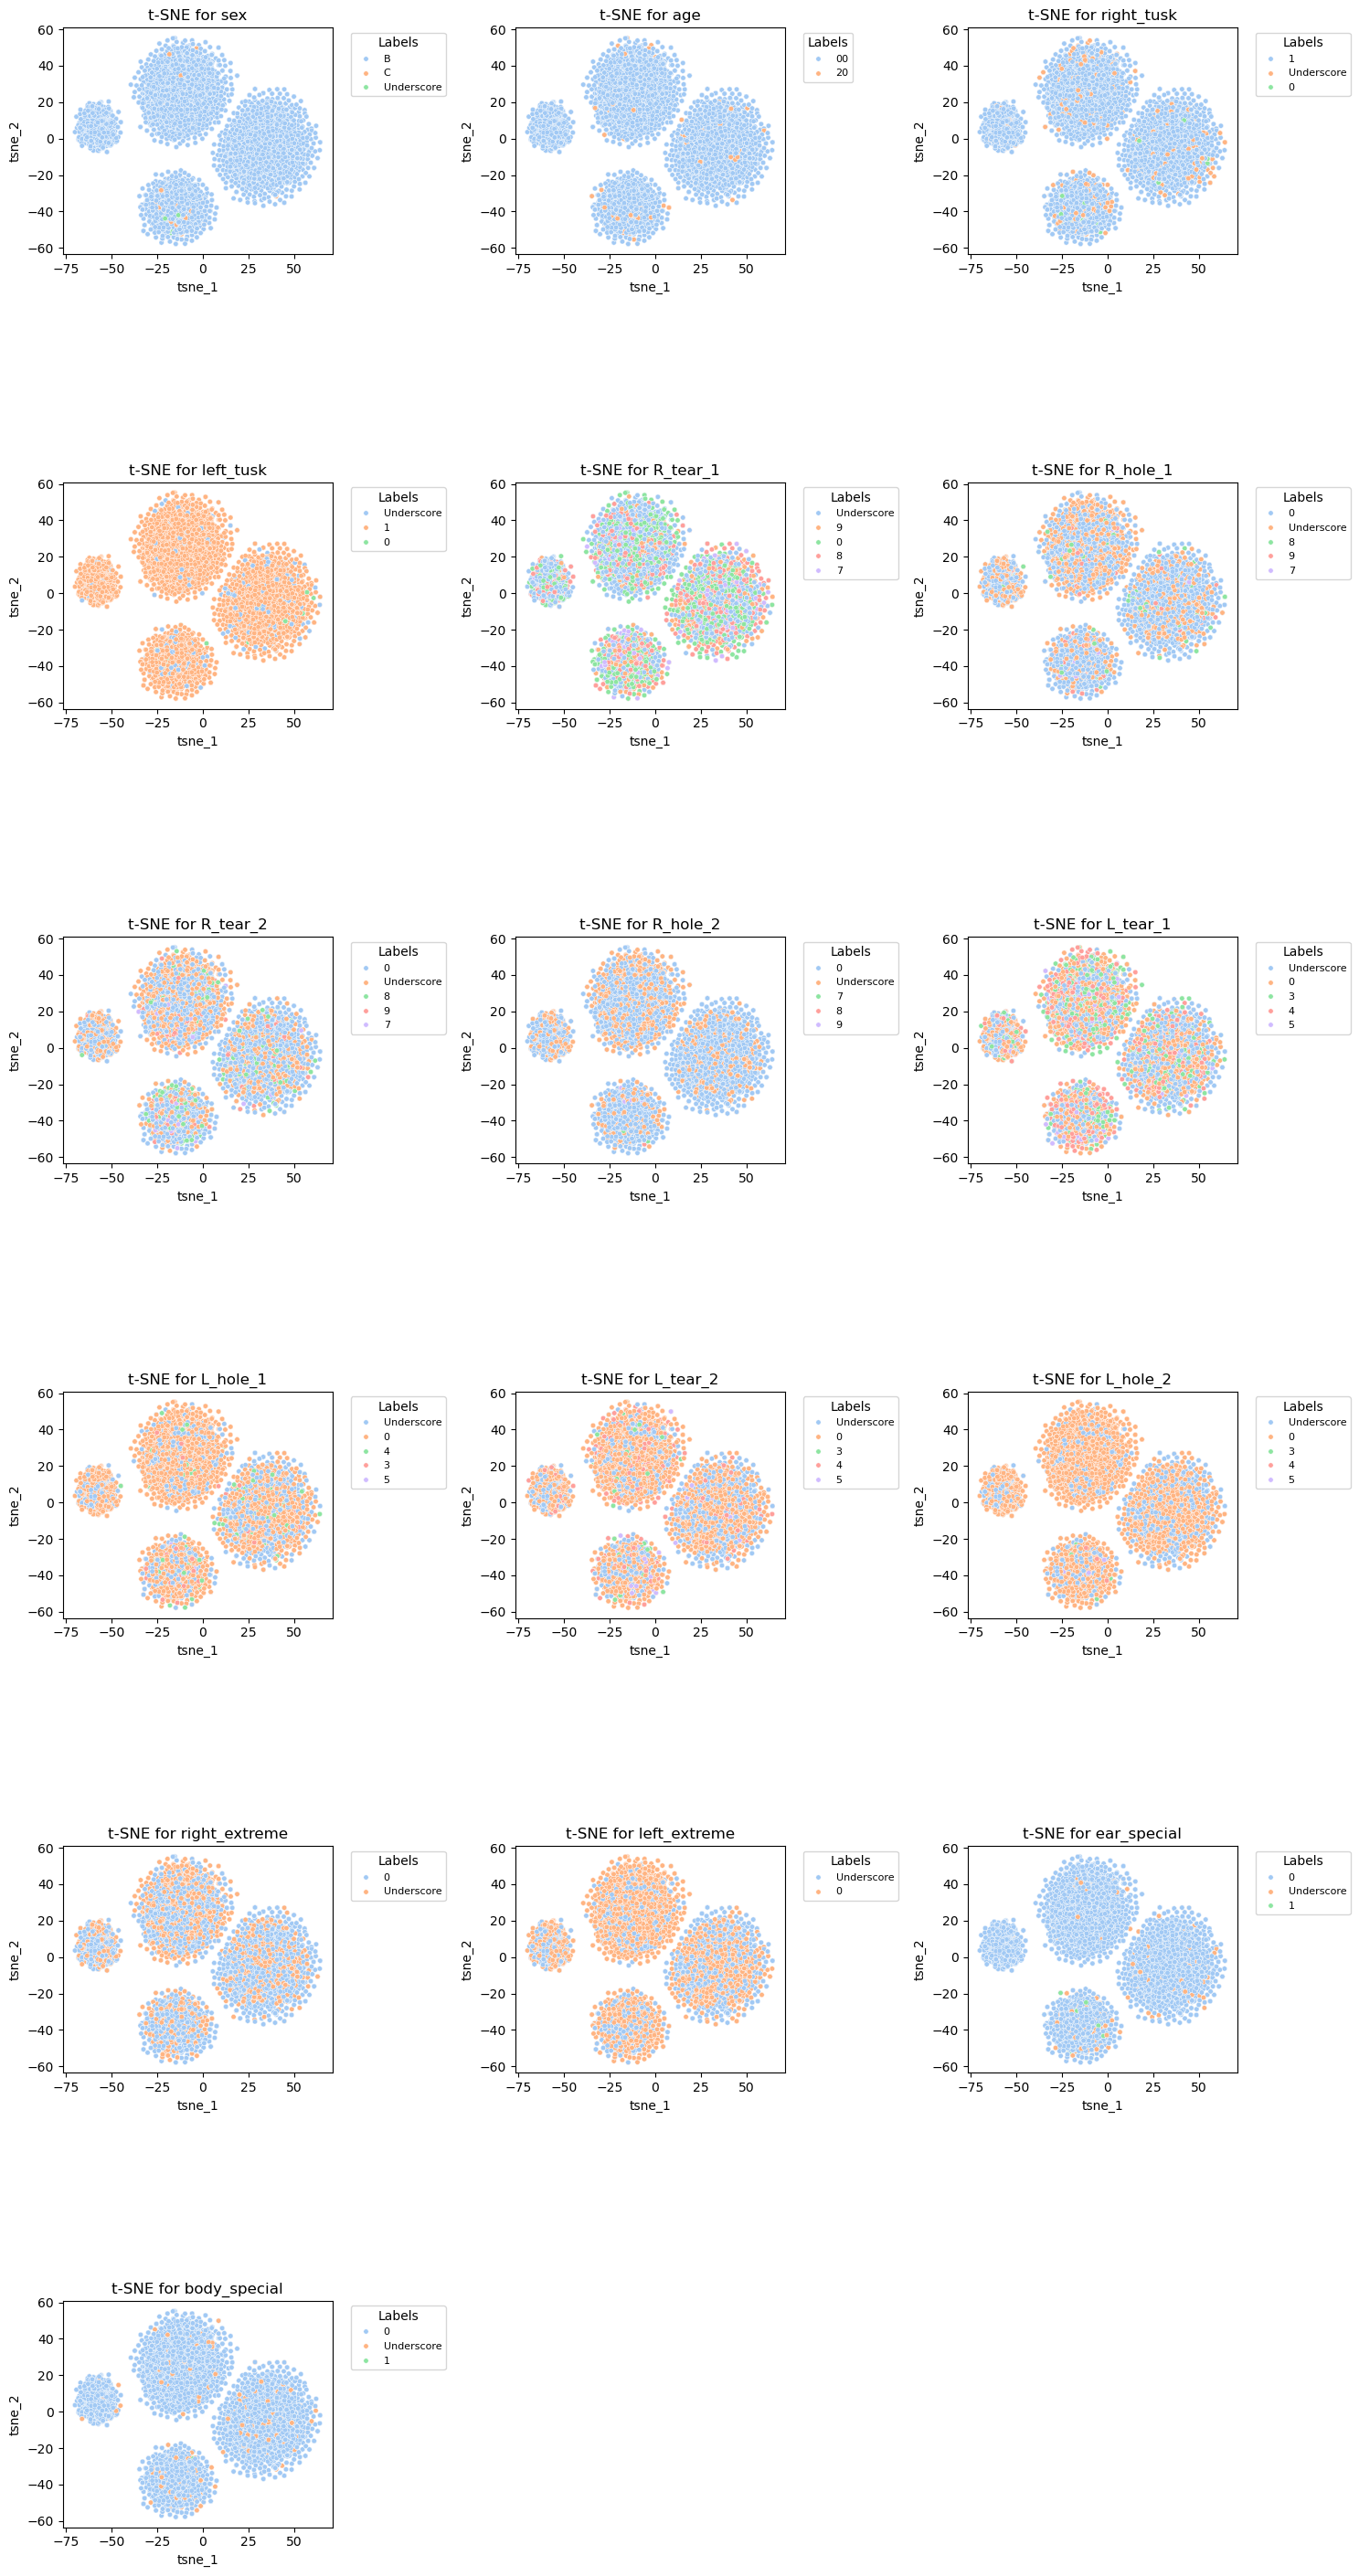

In [124]:
# Prepare grid dimensions
num_attributes = len(SEEK.attribute_names)
num_cols = 3
num_rows = (num_attributes + num_cols - 1) // num_cols

fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, num_rows * 5))
# Perform t-SNE
tsne = TSNE(n_components=2, perplexity=15, random_state=42)
tsne_result = tsne.fit_transform(embeddings)

# Loop through attributes
for i, attribute in enumerate(SEEK.attribute_names):


    # Get labels for coloring
    y = [getattr(SEEK(predictions[j]), attribute) for j in range(len(predictions))]

    # Create a DataFrame for plotting
    tsne_result_df = pd.DataFrame({'tsne_1': tsne_result[:, 0], 'tsne_2': tsne_result[:, 1], 'label': y})
    # Replace "_" with "Underscore" or similar
    tsne_result_df['label'] = tsne_result_df['label'].replace("_", "Underscore")


    # Plot scatterplot
    ax = axes[i // num_cols, i % num_cols]
    sns.scatterplot(
        x='tsne_1', 
        y='tsne_2', 
        hue='label', 
        data=tsne_result_df, 
        ax=ax, 
        s=15, 
        palette='pastel'  # Customize palette as needed
    )
    ax.set_title(f't-SNE for {attribute}', fontsize=12)
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Labels', fontsize=8)
    ax.set_aspect('equal')



# Remove unused subplots
for j in range(num_attributes, num_rows * num_cols):
    fig.delaxes(axes[j // num_cols, j % num_cols])

# Tight layout for neat display
plt.tight_layout()
plt.show()